# 03 — MDM2 pIC50 ExtraTrees Modeling and Interpretation

## Overview

This notebook develops, optimizes, evaluates, simplifies, and interprets a ligand-based QSAR regression model for predicting MDM2 inhibitory potency.

The molecular feature dataset generated in Notebook 02 contains PaDEL 1D/2D descriptors together with Morgan fingerprint information. For the final QSAR workflow, chirality-aware Morgan fingerprints are generated directly from the standardized molecular SMILES using radius 2 and 2048 bits so that stereochemical information is represented in the molecular feature space.

Model development is performed using a Bemis–Murcko scaffold-based train/validation/test partition of approximately 70%/15%/15%. Molecules sharing the same scaffold are kept within the same partition to reduce structural leakage between closely related chemical series.

All data-dependent preprocessing operations are learned exclusively from the training partition and then applied unchanged to the validation and test sets. These steps include training-set missingness filtering, median imputation, and removal of zero-variance PaDEL descriptors and Morgan fingerprint bits.

The workflow includes:

1. generation of Bemis–Murcko scaffolds,
2. scaffold-based train/validation/test partitioning and scaffold-overlap quality control,
3. preparation of PaDEL descriptors and chirality-aware Morgan fingerprints,
4. training-only descriptor preprocessing and removal of uninformative features,
5. combination of the processed PaDEL and Morgan feature representations,
6. baseline regression benchmarking using LazyPredict,
7. selection of ExtraTreesRegressor as the primary QSAR algorithm,
8. training and evaluation of a baseline ExtraTrees model,
9. scaffold-aware hyperparameter optimization using GridSearchCV with GroupKFold,
10. training and evaluation of the optimized full-feature ExtraTrees model,
11. model-based feature-importance analysis,
12. generation of molecule-level predictions and residual diagnostics,
13. cumulative feature-importance reduction using validation performance,
14. independent evaluation of the selected reduced-feature model,
15. comparison of the full and reduced ExtraTrees models,
16. export of the reduced model and the preprocessing and feature-selection information required for downstream prediction.

The optimized full-feature model contained 3,086 molecular features. A subsequent cumulative feature-importance analysis was performed to determine whether a substantially smaller representation could retain comparable predictive performance.

Candidate subsets corresponding to 95%, 97.5%, 99%, and 100% cumulative ExtraTrees feature importance were retrained using the same optimized hyperparameters. Feature-subset selection was performed using validation performance, with the smallest subset whose validation RMSE remained within 0.005 of the best validation RMSE considered acceptable.

This procedure selected a reduced representation containing 1,278 features, corresponding to 95% of cumulative model importance.

The independent test partition was not used for preprocessing, hyperparameter optimization, feature ranking, or reduced-feature subset selection. The feature-reduction analysis was conducted after evaluation of the full model and is therefore interpreted as a post-hoc model-simplification analysis.

The resulting reduced model provides a substantially more compact molecular representation while retaining essentially the same predictive performance as the full ExtraTrees model.


### Final QSAR Model Summary

The MDM2 pIC50 QSAR workflow began with a combined molecular representation consisting of PaDEL 1D/2D descriptors and chirality-aware Morgan fingerprints.

The initial candidate feature space contained 3,492 predictive features:

- 1,444 PaDEL 1D/2D descriptors
- 2,048 Morgan fingerprint bits

After training-set missingness filtering, median imputation, and zero-variance feature removal, the full processed feature matrix contained 3,086 features:

- 1,092 PaDEL descriptors
- 1,994 Morgan fingerprint bits

The dataset contained 4,048 molecules and was partitioned using a Bemis–Murcko scaffold-based split:

- Training: 2,834 molecules
- Validation: 607 molecules
- Test: 607 molecules

The optimized ExtraTreesRegressor configuration used:

- `n_estimators = 1000`
- `max_features = 0.20`
- `min_samples_leaf = 1`
- `min_samples_split = 2`
- `criterion = "squared_error"`
- `bootstrap = False`
- `random_state = 42`

Performance of the full 3,086-feature model was:

| Dataset | RMSE | MAE | R² |
|---|---:|---:|---:|
| Train | 0.0668 | 0.0034 | 0.9975 |
| Validation | 0.5814 | 0.4299 | 0.7307 |
| Test | 0.6119 | 0.4398 | 0.7321 |

Cumulative feature-importance reduction selected a 1,278-feature representation corresponding to 95% of the total ExtraTrees feature importance.

Performance of the reduced 1,278-feature model was:

| Dataset | RMSE | MAE | R² |
|---|---:|---:|---:|
| Train | 0.0717 | 0.0055 | 0.9971 |
| Validation | 0.5853 | 0.4345 | 0.7271 |
| Test | 0.6137 | 0.4401 | 0.7305 |

The feature count was therefore reduced from 3,086 to 1,278, corresponding to an approximately 58.6% reduction in dimensionality.

Despite this substantial reduction, predictive performance changed only minimally. Test R² decreased from 0.7321 to 0.7305, while test RMSE changed from 0.6119 to 0.6137.

The reduced ExtraTrees model therefore retains essentially equivalent predictive performance while providing a more compact and computationally efficient molecular representation. The 1,278-feature model was selected for downstream deployment.

## Step 1 — Load the Combined Molecular Feature Dataset

The input to this notebook is the combined molecular feature table generated in Notebook 02.

The dataset contains:

- standardized molecular SMILES,
- experimental pIC50 values,
- precomputed PaDEL 1D/2D descriptors,
- Morgan fingerprint bits.

No model-dependent preprocessing is performed at this stage.

This step loads the complete feature dataset and verifies that the molecular identifiers, structures, activity values, and feature representations required for subsequent scaffold splitting and model development are available.

In [94]:
# ============================================================
# Step 1 — Load Notebook 02 Feature Dataset
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd


PROJECT_ROOT = Path(
    "/Users/maryta/Downloads/mdm2_Reinvent_4_final"
)

FEATURE_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "qsar_features"
    / "mdm2_padel_1d2d_morgan_features.csv"
)


SMILES_COLUMN = "standardized_smiles"
TARGET_COLUMN = "pIC50"
ID_COLUMN = "Name"


if not FEATURE_FILE.exists():
    raise FileNotFoundError(
        f"Feature dataset not found:\n{FEATURE_FILE}"
    )


df = pd.read_csv(
    FEATURE_FILE,
    low_memory=False,
).copy()


required_columns = {
    ID_COLUMN,
    SMILES_COLUMN,
    TARGET_COLUMN,
}


missing_required_columns = (
    required_columns - set(df.columns)
)

if missing_required_columns:
    raise ValueError(
        "Missing required columns: "
        f"{sorted(missing_required_columns)}"
    )


print("Feature dataset loaded successfully.")

print(
    "\nDataset shape:",
    df.shape
)

print(
    "Number of molecules:",
    len(df)
)

print(
    "Number of columns:",
    len(df.columns)
)

print(
    "\nRequired columns:"
)

for column in sorted(required_columns):
    print(
        f"{column}:",
        column in df.columns
    )


display(
    df.head()
)

Feature dataset loaded successfully.

Dataset shape: (4048, 3496)
Number of molecules: 4048
Number of columns: 3496

Required columns:
Name: True
pIC50: True
standardized_smiles: True


,Name,padel_molecule_id,standardized_smiles,pIC50,nAcid,ALogP,ALogp2,AMR,apol,naAromAtom,...,Morgan_r2_bit_2038,Morgan_r2_bit_2039,Morgan_r2_bit_2040,Morgan_r2_bit_2041,Morgan_r2_bit_2042,Morgan_r2_bit_2043,Morgan_r2_bit_2044,Morgan_r2_bit_2045,Morgan_r2_bit_2046,Morgan_r2_bit_2047
0,MDM2_000000,MDM2_000000,C#CCC1CN(c2nc3nc(C(=O)O)nc(N[C@H](C)C4CCC4)c3n...,7.465466,1,1.0515,1.105652,83.1599,77.533997,15,...,0,0,0,0,0,0,0,0,0,0
1,MDM2_000001,MDM2_000001,C#Cc1ccc(CN2C(=O)c3cc(C(C)(C)O)cc(F)c3[C@]2(OC...,8.116422,0,0.6833,0.466899,70.9986,80.941997,18,...,0,0,0,0,0,0,0,0,0,0
2,MDM2_000002,MDM2_000002,C#Cc1ccc(CN2C(=O)c3cc(C(C)(C)O)ccc3[C@]2(OCC2(...,7.958607,0,0.2036,0.041453,70.1261,81.051790,18,...,0,0,0,0,0,0,0,0,0,0
3,MDM2_000003,MDM2_000003,C#Cc1ccc(CN2C(=O)c3cc(C(C)(O)CO)cc(F)c3[C@]2(O...,8.283997,0,-0.2049,0.041984,72.5429,81.743997,18,...,0,0,0,0,0,0,0,0,0,0
4,MDM2_000004,MDM2_000004,C#Cc1ccc(CN2C(=O)c3cc([C@@](C)(O)CO)cc(F)c3[C@...,8.283997,0,-0.2049,0.041984,72.5429,81.743997,18,...,0,0,0,0,0,0,0,0,0,0


## Step 2 — Generate Bemis–Murcko Scaffolds

Bemis–Murcko scaffolds are generated from the standardized molecular SMILES to represent the core ring systems and linker framework of each compound.

These scaffold labels are used to group structurally related molecules before dataset partitioning.

To remain consistent with the original QSAR workflow, molecules without a ring-containing Bemis–Murcko scaffold are assigned the label `__ACYCLIC__`.

The scaffold representation does not include stereochemistry and is used only for structural grouping, not as a direct model input feature.

In [51]:
# ============================================================
# Step 2 — Generate Bemis–Murcko Scaffolds
# ============================================================

from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold


def get_murcko_scaffold(smiles):
    """
    Generate a Bemis–Murcko scaffold from a standardized SMILES string.
    """

    if pd.isna(smiles):
        return None

    smiles = str(smiles).strip()

    if not smiles:
        return None

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    scaffold = MurckoScaffold.MurckoScaffoldSmiles(
        mol=mol,
        includeChirality=False,
    )

    # Match the original scaffold workflow
    if scaffold == "":
        return "__ACYCLIC__"

    return scaffold


df["murcko_scaffold"] = (
    df[SMILES_COLUMN]
    .apply(get_murcko_scaffold)
)


print("Scaffold generation complete.")

print(
    "\nNumber of molecules:",
    len(df)
)

print(
    "Missing scaffold values:",
    int(
        df["murcko_scaffold"]
        .isna()
        .sum()
    )
)

print(
    "Unique scaffolds:",
    df["murcko_scaffold"]
    .nunique()
)

print(
    "Acyclic molecules:",
    int(
        (
            df["murcko_scaffold"]
            == "__ACYCLIC__"
        ).sum()
    )
)


display(
    df[
        [
            ID_COLUMN,
            SMILES_COLUMN,
            "murcko_scaffold",
            TARGET_COLUMN,
        ]
    ]
    .head(10)
)

Scaffold generation complete.

Number of molecules: 4048
Missing scaffold values: 0
Unique scaffolds: 1300
Acyclic molecules: 0


,Name,standardized_smiles,murcko_scaffold,pIC50
0,MDM2_000000,C#CCC1CN(c2nc3nc(C(=O)O)nc(N[C@H](C)C4CCC4)c3n...,c1ccc(Cn2c(N3CCOCC3)nc3ncnc(NCC4CCC4)c32)cc1,7.465466
1,MDM2_000001,C#Cc1ccc(CN2C(=O)c3cc(C(C)(C)O)cc(F)c3[C@]2(OC...,O=C1c2ccccc2C(OCC2CC2)(c2ccccc2)N1Cc1ccccc1,8.116422
2,MDM2_000002,C#Cc1ccc(CN2C(=O)c3cc(C(C)(C)O)ccc3[C@]2(OCC2(...,O=C1c2ccccc2C(OCC2CC2)(c2ccccc2)N1Cc1ccccc1,7.958607
3,MDM2_000003,C#Cc1ccc(CN2C(=O)c3cc(C(C)(O)CO)cc(F)c3[C@]2(O...,O=C1c2ccccc2C(OCC2CC2)(c2ccccc2)N1Cc1ccccc1,8.283997
4,MDM2_000004,C#Cc1ccc(CN2C(=O)c3cc([C@@](C)(O)CO)cc(F)c3[C@...,O=C1c2ccccc2C(OCC2CC2)(c2ccccc2)N1Cc1ccccc1,8.283997
5,MDM2_000005,C#Cc1ccc2c(c1)C(=O)N([C@H](C)c1ccc(Cl)cc1)[C@@...,O=C1Nc2ccccc2C(=O)N(Cc2ccccc2)C1c1ccccc1,4.987163
6,MDM2_000015,C=C(C)c1cc(C)nc(-c2nc3nc(C(=O)O)nc(N[C@H](C)C4...,c1ccc(Cn2c(-c3ccccn3)nc3ncnc(NCC4CCC4)c32)cc1,7.299469
7,MDM2_000016,C=C(C)c1nc2cc(-c3noc(=O)[nH]3)nc(-c3cncc(Cl)c3...,O=c1[nH]c(-c2cc3ncn(CC4CCCCC4)c3c(-c3cccnc3)n2...,8.154902
8,MDM2_000017,C=C(CCC)c1nc2cc(-c3noc(=O)[nH]3)nc(-c3cncc(Cl)...,O=c1[nH]c(-c2cc3ncn(CC4CCCCC4)c3c(-c3cccnc3)n2...,8.698970
9,MDM2_000018,C=C(CO)COC1(c2ccc(Cl)cc2)c2ccccc2C(=O)N1Cc1ccc...,O=C1c2ccccc2C(c2ccccc2)N1Cc1ccccc1,6.167491


## Step 3 — Create a Bemis–Murcko Scaffold-Based Train/Validation/Test Split

The molecules are partitioned using their Bemis–Murcko scaffold groups rather than by random molecule-level splitting.

Molecules that share the same scaffold are kept within the same partition so that closely related structural analogues are not distributed across the training, validation, and test sets.

To remain consistent with the original QSAR workflow, the target proportions are approximately:

- 70% training
- 15% validation
- 15% test

Scaffold groups are shuffled reproducibly using a fixed random seed and then ordered by group size. Each complete scaffold group is assigned to the partition with the greatest remaining capacity relative to its target size.

In [52]:
# ============================================================
# Step 3 — Bemis–Murcko Scaffold-Based 70/15/15 Split
# ============================================================

from collections import defaultdict


RANDOM_STATE = 42

TRAIN_FRACTION = 0.70
VALID_FRACTION = 0.15


# ------------------------------------------------------------
# Group molecule indices by scaffold
# ------------------------------------------------------------

scaffold_to_indices = defaultdict(list)

for row_index, scaffold in enumerate(
    df["murcko_scaffold"]
):
    scaffold_to_indices[scaffold].append(
        row_index
    )


# ------------------------------------------------------------
# Reproduce the original scaffold ordering
# ------------------------------------------------------------

rng = np.random.default_rng(
    RANDOM_STATE
)

scaffold_groups = list(
    scaffold_to_indices.values()
)

rng.shuffle(
    scaffold_groups
)

scaffold_groups.sort(
    key=len,
    reverse=True,
)


# ------------------------------------------------------------
# Scaffold split function
# ------------------------------------------------------------

def scaffold_split(
    groups,
    total_size,
    train_fraction=0.70,
    valid_fraction=0.15,
):
    """
    Allocate complete scaffold groups to train,
    validation, and test partitions.
    """

    target_sizes = {
        "train": int(
            round(
                train_fraction
                * total_size
            )
        ),
        "valid": int(
            round(
                valid_fraction
                * total_size
            )
        ),
    }

    target_sizes["test"] = (
        total_size
        - target_sizes["train"]
        - target_sizes["valid"]
    )


    assignments = {
        "train": [],
        "valid": [],
        "test": [],
    }


    for group in groups:

        remaining_capacity = {
            split_name: (
                target_sizes[split_name]
                - len(
                    assignments[split_name]
                )
            )
            for split_name in assignments
        }


        destination = max(
            remaining_capacity,
            key=lambda split_name: (
                remaining_capacity[
                    split_name
                ],
                target_sizes[
                    split_name
                ],
            ),
        )


        assignments[
            destination
        ].extend(group)


    return (
        sorted(
            assignments["train"]
        ),
        sorted(
            assignments["valid"]
        ),
        sorted(
            assignments["test"]
        ),
        target_sizes,
    )


train_indices, valid_indices, test_indices, target_sizes = (
    scaffold_split(
        groups=scaffold_groups,
        total_size=len(df),
        train_fraction=TRAIN_FRACTION,
        valid_fraction=VALID_FRACTION,
    )
)


# ------------------------------------------------------------
# Assign split labels
# ------------------------------------------------------------

df["split"] = None

df.loc[
    train_indices,
    "split"
] = "train"

df.loc[
    valid_indices,
    "split"
] = "validation"

df.loc[
    test_indices,
    "split"
] = "test"


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print(
    "Target sizes:",
    target_sizes
)

print(
    "\nActual split counts:"
)

print(
    df["split"]
    .value_counts()
    .reindex(
        [
            "train",
            "validation",
            "test",
        ]
    )
)

print(
    "\nSplit percentages:"
)

print(
    (
        100
        * df["split"]
        .value_counts(
            normalize=True
        )
        .reindex(
            [
                "train",
                "validation",
                "test",
            ]
        )
    ).round(2)
)

Target sizes: {'train': 2834, 'valid': 607, 'test': 607}

Actual split counts:
split
train         2834
validation     607
test           607
Name: count, dtype: int64

Split percentages:
split
train         70.01
validation    15.00
test          15.00
Name: proportion, dtype: float64


In [53]:
# ============================================================
# Step 3 QC — Confirm Zero Scaffold Overlap
# ============================================================

train_scaffolds = set(
    df.loc[
        df["split"] == "train",
        "murcko_scaffold",
    ]
)

validation_scaffolds = set(
    df.loc[
        df["split"] == "validation",
        "murcko_scaffold",
    ]
)

test_scaffolds = set(
    df.loc[
        df["split"] == "test",
        "murcko_scaffold",
    ]
)


print(
    "Train-validation scaffold overlap:",
    len(
        train_scaffolds
        & validation_scaffolds
    )
)

print(
    "Train-test scaffold overlap:",
    len(
        train_scaffolds
        & test_scaffolds
    )
)

print(
    "Validation-test scaffold overlap:",
    len(
        validation_scaffolds
        & test_scaffolds
    )
)

Train-validation scaffold overlap: 0
Train-test scaffold overlap: 0
Validation-test scaffold overlap: 0


## Step 4 — Separate Molecular Feature Groups

The combined dataset contains both predictive molecular features and non-predictive metadata.

Before preprocessing, the columns are separated into three groups:

1. **PaDEL 1D/2D descriptors**
2. **Morgan fingerprint bits**
3. **Metadata**, including molecular identifiers, standardized SMILES, experimental pIC50 values, scaffold labels, and train/validation/test split assignments

Metadata columns are excluded from the machine-learning feature matrix so that only molecular descriptors and fingerprints are used as model inputs.

In [56]:
# ============================================================
# Step 4 — Separate Molecular Feature Groups
# ============================================================

metadata_columns = {
    ID_COLUMN,
    "padel_molecule_id",
    SMILES_COLUMN,
    TARGET_COLUMN,
    "murcko_scaffold",
    "scaffold",
    "split",
}


# Morgan fingerprint columns
morgan_columns = [
    column
    for column in df.columns
    if str(column).startswith("Morgan_r2_bit_")
]


# PaDEL descriptor columns
padel_columns = [
    column
    for column in df.columns
    if (
        column not in metadata_columns
        and column not in morgan_columns
    )
]


print(
    "PaDEL descriptor columns:",
    len(padel_columns)
)

print(
    "Morgan fingerprint bits:",
    len(morgan_columns)
)

print(
    "Total candidate predictive features:",
    len(padel_columns)
    + len(morgan_columns)
)

print("\nFirst 10 PaDEL descriptors:")
print(
    padel_columns[:10]
)

print("\nFirst 10 Morgan bits:")
print(
    morgan_columns[:10]
)

PaDEL descriptor columns: 1444
Morgan fingerprint bits: 2048
Total candidate predictive features: 3492

First 10 PaDEL descriptors:
['nAcid', 'ALogP', 'ALogp2', 'AMR', 'apol', 'naAromAtom', 'nAromBond', 'nAtom', 'nHeavyAtom', 'nH']

First 10 Morgan bits:
['Morgan_r2_bit_0000', 'Morgan_r2_bit_0001', 'Morgan_r2_bit_0002', 'Morgan_r2_bit_0003', 'Morgan_r2_bit_0004', 'Morgan_r2_bit_0005', 'Morgan_r2_bit_0006', 'Morgan_r2_bit_0007', 'Morgan_r2_bit_0008', 'Morgan_r2_bit_0009']


### Step 4B — Generate Chirality-Aware Morgan Fingerprints

Morgan fingerprints are generated directly from the standardized molecular SMILES using radius 2 and 2048 bits.

Chirality information is included so that stereochemical differences between molecules are represented in the fingerprint feature space.

These fingerprints are used as the Morgan feature representation for subsequent preprocessing and model development.

In [77]:
# ============================================================
# Step 4B — Generate Chirality-Aware Morgan Fingerprints
# ============================================================

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator


MORGAN_RADIUS = 2
MORGAN_BITS = 2048
MORGAN_USE_CHIRALITY = True


morgan_generator = (
    rdFingerprintGenerator.GetMorganGenerator(
        radius=MORGAN_RADIUS,
        fpSize=MORGAN_BITS,
        includeChirality=MORGAN_USE_CHIRALITY,
    )
)


def smiles_to_morgan(smiles):
    """
    Convert a standardized SMILES string into
    a chirality-aware Morgan fingerprint.
    """

    if pd.isna(smiles):
        return None

    smiles = str(smiles).strip()

    if not smiles:
        return None

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    fingerprint = (
        morgan_generator
        .GetFingerprint(mol)
    )

    fingerprint_array = np.zeros(
        MORGAN_BITS,
        dtype=np.uint8,
    )

    DataStructs.ConvertToNumpyArray(
        fingerprint,
        fingerprint_array,
    )

    return fingerprint_array


morgan_arrays = []
invalid_smiles_rows = []


for row_position, smiles in enumerate(
    df[SMILES_COLUMN]
):

    fingerprint_array = smiles_to_morgan(
        smiles
    )

    if fingerprint_array is None:
        invalid_smiles_rows.append(
            row_position
        )
    else:
        morgan_arrays.append(
            fingerprint_array
        )


if invalid_smiles_rows:
    raise ValueError(
        f"{len(invalid_smiles_rows)} invalid SMILES were found. "
        f"First invalid row positions: {invalid_smiles_rows[:20]}"
    )


X_morgan_all = np.vstack(
    morgan_arrays
)


morgan_feature_names = [
    f"Morgan_r{MORGAN_RADIUS}_bit_{bit_number:04d}"
    for bit_number in range(MORGAN_BITS)
]


print(
    "Morgan fingerprint generation complete."
)

print(
    "Radius:",
    MORGAN_RADIUS
)

print(
    "Fingerprint size:",
    MORGAN_BITS
)

print(
    "Chirality included:",
    MORGAN_USE_CHIRALITY
)

print(
    "Morgan matrix shape:",
    X_morgan_all.shape
)

Morgan fingerprint generation complete.
Radius: 2
Fingerprint size: 2048
Chirality included: True
Morgan matrix shape: (4048, 2048)


## Step 5 — Clean PaDEL Descriptor Values

PaDEL descriptor columns may contain non-numeric entries, infinite values, or extremely large numerical values that can cause problems during model preprocessing.

In this step:

- non-numeric values are converted to missing values (`NaN`),
- positive and negative infinity values are converted to `NaN`,
- extremely large absolute values are converted to `NaN`.

This step does not learn any statistics from the dataset. It only standardizes invalid numerical entries before the train/validation/test-specific preprocessing steps.

In [58]:
# ============================================================
# Step 5 — Clean PaDEL Descriptor Values
# ============================================================

EXTREME_VALUE_LIMIT = 1e100


def safe_numeric_dataframe(dataframe):
    """
    Convert a DataFrame to numeric values and replace
    invalid, infinite, or extreme values with NaN.
    """

    numeric_df = dataframe.apply(
        pd.to_numeric,
        errors="coerce",
    )

    numeric_df = numeric_df.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    numeric_df = numeric_df.mask(
        numeric_df.abs() > EXTREME_VALUE_LIMIT,
        np.nan,
    )

    return numeric_df


X_padel_all = safe_numeric_dataframe(
    df[padel_columns]
)


print(
    "PaDEL matrix shape:",
    X_padel_all.shape
)

print(
    "Total missing values after cleaning:",
    int(
        X_padel_all
        .isna()
        .sum()
        .sum()
    )
)

print(
    "Descriptors containing at least one missing value:",
    int(
        X_padel_all
        .isna()
        .any(axis=0)
        .sum()
    )
)


padel_array_for_check = (
    X_padel_all.to_numpy(
        dtype=np.float64
    )
)

print(
    "Remaining infinite values:",
    int(
        np.isinf(
            padel_array_for_check
        ).sum()
    )
)

PaDEL matrix shape: (4048, 1444)
Total missing values after cleaning: 606373
Descriptors containing at least one missing value: 818
Remaining infinite values: 0


## Step 6 — Create Train, Validation, and Test Matrices

The scaffold-based split assignments are used to separate the processed molecular features and experimental pIC50 values into training, validation, and test partitions.

The PaDEL descriptors have undergone only numerical cleaning at this stage.

The Morgan fingerprints used here are the chirality-aware fingerprints generated directly from the standardized SMILES in Step 4B.

No missingness filtering, imputation, variance filtering, or model fitting has yet been performed.

In [78]:
# ============================================================
# Step 6 — Create Train / Validation / Test Matrices
# ============================================================

train_mask = (
    df["split"]
    .eq("train")
    .to_numpy()
)

validation_mask = (
    df["split"]
    .eq("validation")
    .to_numpy()
)

test_mask = (
    df["split"]
    .eq("test")
    .to_numpy()
)


# ------------------------------------------------------------
# Target values
# ------------------------------------------------------------

y_all = (
    pd.to_numeric(
        df[TARGET_COLUMN],
        errors="coerce",
    )
    .to_numpy(dtype=float)
)

if np.isnan(y_all).any():
    raise ValueError(
        "Missing or invalid pIC50 values were detected."
    )


y_train = y_all[train_mask]
y_validation = y_all[validation_mask]
y_test = y_all[test_mask]


# ------------------------------------------------------------
# PaDEL descriptor matrices
# ------------------------------------------------------------

X_padel_train_raw = (
    X_padel_all
    .loc[train_mask]
    .copy()
)

X_padel_validation_raw = (
    X_padel_all
    .loc[validation_mask]
    .copy()
)

X_padel_test_raw = (
    X_padel_all
    .loc[test_mask]
    .copy()
)


# ------------------------------------------------------------
# Chirality-aware Morgan fingerprint matrices
# ------------------------------------------------------------

X_morgan_train_raw = (
    X_morgan_all[train_mask]
)

X_morgan_validation_raw = (
    X_morgan_all[validation_mask]
)

X_morgan_test_raw = (
    X_morgan_all[test_mask]
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("Target sizes:")
print("Train:", len(y_train))
print("Validation:", len(y_validation))
print("Test:", len(y_test))

print("\nPaDEL matrices:")
print("Train:", X_padel_train_raw.shape)
print("Validation:", X_padel_validation_raw.shape)
print("Test:", X_padel_test_raw.shape)

print("\nMorgan matrices:")
print("Train:", X_morgan_train_raw.shape)
print("Validation:", X_morgan_validation_raw.shape)
print("Test:", X_morgan_test_raw.shape)

Target sizes:
Train: 2834
Validation: 607
Test: 607

PaDEL matrices:
Train: (2834, 1444)
Validation: (607, 1444)
Test: (607, 1444)

Morgan matrices:
Train: (2834, 2048)
Validation: (607, 2048)
Test: (607, 2048)


## Step 7 — Filter PaDEL Descriptors by Training-Set Missingness

PaDEL descriptors with more than 20% missing values in the training partition are removed before imputation.

The missingness threshold is calculated using only the training data. The same retained descriptor set is then applied unchanged to the validation and test partitions.

This prevents validation or test information from influencing feature preprocessing.

In [61]:
# ============================================================
# Step 7 — Filter PaDEL Descriptors by Training Missingness
# ============================================================

MISSINGNESS_THRESHOLD = 0.20


# Calculate missingness using TRAINING DATA ONLY
training_missing_fraction = (
    X_padel_train_raw
    .isna()
    .mean()
)


# Retain descriptors with <= 20% missing values
selected_after_missingness = (
    training_missing_fraction[
        training_missing_fraction
        <= MISSINGNESS_THRESHOLD
    ]
    .index
    .tolist()
)


# Record descriptors removed at this stage
removed_for_missingness = sorted(
    set(padel_columns)
    - set(selected_after_missingness)
)


# Apply the training-derived feature set
# unchanged to all partitions
X_padel_train_raw = (
    X_padel_train_raw[
        selected_after_missingness
    ]
    .copy()
)

X_padel_validation_raw = (
    X_padel_validation_raw[
        selected_after_missingness
    ]
    .copy()
)

X_padel_test_raw = (
    X_padel_test_raw[
        selected_after_missingness
    ]
    .copy()
)


print(
    "Original PaDEL descriptors:",
    len(padel_columns)
)

print(
    "Removed for >20% training missingness:",
    len(removed_for_missingness)
)

print(
    "PaDEL descriptors retained:",
    len(selected_after_missingness)
)

print("\nFiltered matrix shapes:")
print("Train:", X_padel_train_raw.shape)
print("Validation:", X_padel_validation_raw.shape)
print("Test:", X_padel_test_raw.shape)

Original PaDEL descriptors: 1444
Removed for >20% training missingness: 99
PaDEL descriptors retained: 1345

Filtered matrix shapes:
Train: (2834, 1345)
Validation: (607, 1345)
Test: (607, 1345)


## Step 8 — Remove Completely Missing Training Descriptors

After missingness filtering, the retained PaDEL descriptors are checked for columns containing no observed values in the training partition.

A descriptor that is completely missing in the training set cannot provide useful information for model development and does not have a valid training-set median for subsequent imputation.

Any such descriptor is removed from the training, validation, and test partitions using the training-set decision only.

In [62]:
# ============================================================
# Step 8 — Remove Completely Missing Training Descriptors
# ============================================================

all_missing_training_columns = (
    X_padel_train_raw.columns[
        X_padel_train_raw
        .isna()
        .all(axis=0)
    ]
    .tolist()
)


if all_missing_training_columns:

    X_padel_train_raw = (
        X_padel_train_raw.drop(
            columns=all_missing_training_columns
        )
    )

    X_padel_validation_raw = (
        X_padel_validation_raw.drop(
            columns=all_missing_training_columns
        )
    )

    X_padel_test_raw = (
        X_padel_test_raw.drop(
            columns=all_missing_training_columns
        )
    )


selected_after_missingness = (
    X_padel_train_raw
    .columns
    .tolist()
)


print(
    "Completely missing descriptors in training:",
    len(all_missing_training_columns)
)

print(
    "Descriptors entering imputation:",
    len(selected_after_missingness)
)

print("\nMatrix shapes:")
print(
    "Train:",
    X_padel_train_raw.shape
)
print(
    "Validation:",
    X_padel_validation_raw.shape
)
print(
    "Test:",
    X_padel_test_raw.shape
)

Completely missing descriptors in training: 0
Descriptors entering imputation: 1345

Matrix shapes:
Train: (2834, 1345)
Validation: (607, 1345)
Test: (607, 1345)


## Step 9 — Impute Remaining Missing PaDEL Values

After removing descriptors with excessive or complete training-set missingness, the remaining missing PaDEL values are imputed using the median of each descriptor.

The imputer is fitted using only the training partition. The learned median values are then applied unchanged to the validation and test partitions.

This preserves the original preprocessing logic while preventing information from the validation or test sets from influencing the model-development process.

In [63]:
# ============================================================
# Step 9 — Training-Only Median Imputation
# ============================================================

from sklearn.impute import SimpleImputer


imputer = SimpleImputer(
    strategy="median"
)


# Fit on training data only
X_padel_train_imputed = (
    imputer.fit_transform(
        X_padel_train_raw
    )
)


# Apply the fitted imputer unchanged
X_padel_validation_imputed = (
    imputer.transform(
        X_padel_validation_raw
    )
)

X_padel_test_imputed = (
    imputer.transform(
        X_padel_test_raw
    )
)


print("Median imputation complete.")

print("\nMatrix shapes:")
print(
    "Train:",
    X_padel_train_imputed.shape
)
print(
    "Validation:",
    X_padel_validation_imputed.shape
)
print(
    "Test:",
    X_padel_test_imputed.shape
)


print("\nRemaining missing values:")
print(
    "Train:",
    int(
        np.isnan(
            X_padel_train_imputed
        ).sum()
    )
)

print(
    "Validation:",
    int(
        np.isnan(
            X_padel_validation_imputed
        ).sum()
    )
)

print(
    "Test:",
    int(
        np.isnan(
            X_padel_test_imputed
        ).sum()
    )
)

Median imputation complete.

Matrix shapes:
Train: (2834, 1345)
Validation: (607, 1345)
Test: (607, 1345)

Remaining missing values:
Train: 0
Validation: 0
Test: 0


## Step 10 — Remove Zero-Variance Features

After imputation, features that show no variation across the training molecules are removed.

A zero-variance feature has the same value for every molecule in the training partition and therefore cannot contribute to distinguishing compounds or predicting pIC50.

Variance filtering is performed separately for the PaDEL descriptors and Morgan fingerprint bits. Each filter is fitted using only the training partition and then applied unchanged to the validation and test sets.

In [81]:
# ============================================================
# Step 10 — Remove Zero-Variance Features
# ============================================================

from sklearn.feature_selection import VarianceThreshold


# ------------------------------------------------------------
# PaDEL descriptors
# ------------------------------------------------------------

variance_filter_padel = VarianceThreshold(
    threshold=0.0
)

X_padel_train = (
    variance_filter_padel
    .fit_transform(
        X_padel_train_imputed
    )
)

X_padel_validation = (
    variance_filter_padel
    .transform(
        X_padel_validation_imputed
    )
)

X_padel_test = (
    variance_filter_padel
    .transform(
        X_padel_test_imputed
    )
)


selected_padel_mask = (
    variance_filter_padel
    .get_support()
)

selected_padel_descriptors = (
    np.asarray(
        selected_after_missingness
    )[selected_padel_mask]
    .tolist()
)

removed_constant_padel = (
    np.asarray(
        selected_after_missingness
    )[~selected_padel_mask]
    .tolist()
)


# ------------------------------------------------------------
# Morgan fingerprint bits
# ------------------------------------------------------------

variance_filter_morgan = VarianceThreshold(
    threshold=0.0
)

X_morgan_train = (
    variance_filter_morgan
    .fit_transform(
        X_morgan_train_raw
    )
)

X_morgan_validation = (
    variance_filter_morgan
    .transform(
        X_morgan_validation_raw
    )
)

X_morgan_test = (
    variance_filter_morgan
    .transform(
        X_morgan_test_raw
    )
)


selected_morgan_mask = (
    variance_filter_morgan
    .get_support()
)


# IMPORTANT:
# Use the feature names created for the chirality-aware
# Morgan fingerprint matrix in Step 4B.
selected_morgan_features = (
    np.asarray(
        morgan_feature_names
    )[selected_morgan_mask]
    .tolist()
)

removed_constant_morgan = (
    np.asarray(
        morgan_feature_names
    )[~selected_morgan_mask]
    .tolist()
)


# ------------------------------------------------------------
# Quality checks
# ------------------------------------------------------------

if X_padel_train.shape[1] != len(
    selected_padel_descriptors
):
    raise ValueError(
        "PaDEL feature-name count does not match "
        "the filtered PaDEL matrix."
    )


if X_morgan_train.shape[1] != len(
    selected_morgan_features
):
    raise ValueError(
        "Morgan feature-name count does not match "
        "the filtered Morgan matrix."
    )


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("PaDEL:")

print(
    "Before variance filtering:",
    X_padel_train_imputed.shape[1]
)

print(
    "After variance filtering:",
    X_padel_train.shape[1]
)

print(
    "Constant descriptors removed:",
    len(removed_constant_padel)
)


print("\nMorgan:")

print(
    "Before variance filtering:",
    X_morgan_train_raw.shape[1]
)

print(
    "After variance filtering:",
    X_morgan_train.shape[1]
)

print(
    "Constant bits removed:",
    len(removed_constant_morgan)
)

PaDEL:
Before variance filtering: 1345
After variance filtering: 1092
Constant descriptors removed: 253

Morgan:
Before variance filtering: 2048
After variance filtering: 1994
Constant bits removed: 54


## Step 11 — Combine the Processed PaDEL and Morgan Features

After training-based preprocessing, the retained PaDEL descriptors and Morgan fingerprint bits are combined into a single molecular feature matrix.

The PaDEL descriptors provide physicochemical and structural information, whereas Morgan fingerprints encode local molecular substructures.

The same feature order is maintained across the training, validation, and test partitions.

No model fitting or hyperparameter optimization is performed in this step.

In [80]:
# ============================================================
# Step 11 — Combine Processed PaDEL + Morgan Features
# ============================================================

X_train = np.hstack([
    X_padel_train.astype(np.float32),
    X_morgan_train.astype(np.float32),
])

X_validation = np.hstack([
    X_padel_validation.astype(np.float32),
    X_morgan_validation.astype(np.float32),
])

X_test = np.hstack([
    X_padel_test.astype(np.float32),
    X_morgan_test.astype(np.float32),
])


# ------------------------------------------------------------
# Combined feature names
# ------------------------------------------------------------

combined_feature_names = (
    selected_padel_descriptors
    + selected_morgan_features
)


combined_feature_types = (
    ["PaDEL_descriptor"]
    * len(selected_padel_descriptors)
    +
    ["Morgan_bit"]
    * len(selected_morgan_features)
)


# ------------------------------------------------------------
# Quality checks
# ------------------------------------------------------------

assert X_train.shape[1] == len(
    combined_feature_names
)

assert X_validation.shape[1] == len(
    combined_feature_names
)

assert X_test.shape[1] == len(
    combined_feature_names
)

assert np.isfinite(X_train).all()
assert np.isfinite(X_validation).all()
assert np.isfinite(X_test).all()


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print(
    "Combined feature matrices created successfully."
)

print("\nFinal matrix shapes:")
print(
    "Train:",
    X_train.shape
)
print(
    "Validation:",
    X_validation.shape
)
print(
    "Test:",
    X_test.shape
)

print("\nFeature composition:")
print(
    "PaDEL descriptors:",
    len(selected_padel_descriptors)
)
print(
    "Morgan bits:",
    len(selected_morgan_features)
)
print(
    "Total features:",
    len(combined_feature_names)
)

Combined feature matrices created successfully.

Final matrix shapes:
Train: (2834, 3086)
Validation: (607, 3086)
Test: (607, 3086)

Feature composition:
PaDEL descriptors: 1092
Morgan bits: 1994
Total features: 3086


### Note on Feature Dimensionality

After preprocessing and zero-variance filtering, the final molecular representation contained 3,086 predictive features, including 1,092 PaDEL descriptors and 1,994 Morgan fingerprint bits.

Although the feature space is high-dimensional relative to the number of training compounds, this representation was retained because ExtraTrees can accommodate nonlinear high-dimensional inputs and because predictive performance was evaluated using scaffold-separated validation and test sets.

The close agreement between validation and test performance provides evidence that the retained feature representation generalizes consistently to structurally distinct compounds.

## Step 12 — Benchmark Regression Models with LazyPredict

Before selecting the final regression algorithm, multiple standard regression models are benchmarked using the same processed molecular feature representation.

LazyPredict is used to train a collection of baseline regression algorithms on the training partition and evaluate them on the validation partition without model-specific hyperparameter optimization.

This provides a consistent initial comparison across regression methods and helps justify the selection of ExtraTrees for subsequent hyperparameter tuning.

The independent test set is not used during benchmarking or model selection.

In [66]:
# ============================================================
# Step 12 — Regression Model Benchmarking with LazyPredict
# ============================================================

from lazypredict.Supervised import LazyRegressor


benchmark = LazyRegressor(
    verbose=0,
    ignore_warnings=True,
    custom_metric=None,
)


benchmark_results, benchmark_predictions = benchmark.fit(
    X_train,
    X_validation,
    y_train,
    y_validation,
)


print("LazyPredict benchmarking complete.")

display(
    benchmark_results
)

High-dimensional dataset (3068 features). Some models may be slow or fail. Consider dimensionality reduction.


LazyPredict benchmarking complete.


,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
SGDRegressor,7.628422e+22,-3.099204e+23,6.237124e+11,0.913433
Lars,7.006121e+09,-2.846381e+10,1.890192e+05,0.457303
TransformedTargetRegressor,7.718737e+03,-3.135390e+04,1.983865e+02,1.080301
LinearRegression,7.718737e+03,-3.135390e+04,1.983865e+02,1.070119
GaussianProcessRegressor,1.306032e+01,-4.799754e+01,7.842354e+00,138.417332
KernelRidge,8.783884e+00,-3.062363e+01,6.300358e+00,0.256714
Ridge,2.230503e+00,-3.999170e+00,2.505003e+00,0.188934
LinearSVR,2.219485e+00,-3.954408e+00,2.493763e+00,10.577795
MLPRegressor,1.484889e+00,-9.699625e-01,1.572491e+00,1.603408


### Benchmarking Conclusion

The LazyPredict benchmark showed that ensemble tree-based methods provided the strongest predictive performance for the current PaDEL + Morgan feature representation.

Among the evaluated regression algorithms, **ExtraTreesRegressor achieved the best validation performance**, with an R² of approximately **0.67** and an RMSE of approximately **0.64**. Its performance was slightly better than RandomForestRegressor and HistGradientBoostingRegressor and also exceeded that of XGBRegressor in this baseline comparison.

Based on these results, **ExtraTreesRegressor was selected as the primary regression algorithm for subsequent model development and hyperparameter optimization**.

The independent test set was not used during this benchmarking and model-selection stage.

## Step 13 — Train and Evaluate a Baseline ExtraTrees Model

Following the regression benchmark, ExtraTreesRegressor was selected as the primary modeling algorithm.

A baseline ExtraTrees model is now trained using the processed PaDEL + Morgan feature matrix without model-specific hyperparameter optimization.

The model is fitted on the training partition and evaluated on the validation partition to establish a reference performance before hyperparameter tuning.

The independent test set remains untouched at this stage.

In [82]:
# ============================================================
# Step 13 — Baseline ExtraTrees Model
# ============================================================

baseline_extratrees = ExtraTreesRegressor(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

baseline_extratrees.fit(
    X_train,
    y_train,
)

baseline_train_pred = baseline_extratrees.predict(
    X_train
)

baseline_validation_pred = baseline_extratrees.predict(
    X_validation
)

baseline_train_metrics = calculate_metrics(
    y_train,
    baseline_train_pred,
)

baseline_validation_metrics = calculate_metrics(
    y_validation,
    baseline_validation_pred,
)

baseline_results_df = pd.DataFrame([
    {
        "Dataset": "Train",
        **baseline_train_metrics,
    },
    {
        "Dataset": "Validation",
        **baseline_validation_metrics,
    },
])

display(
    baseline_results_df.round(4)
)

,Dataset,RMSE,MAE,R2
0,Train,0.0668,0.0034,0.9975
1,Validation,0.6086,0.4474,0.7049


In [83]:
previous_extratrees = ExtraTreesRegressor(
    n_estimators=1000,
    max_features=0.20,
    min_samples_leaf=2,
    min_samples_split=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

previous_extratrees.fit(
    X_train,
    y_train,
)

previous_train_pred = previous_extratrees.predict(
    X_train
)

previous_validation_pred = previous_extratrees.predict(
    X_validation
)

previous_train_metrics = calculate_metrics(
    y_train,
    previous_train_pred,
)

previous_validation_metrics = calculate_metrics(
    y_validation,
    previous_validation_pred,
)

pd.DataFrame([
    {
        "Dataset": "Train",
        **previous_train_metrics,
    },
    {
        "Dataset": "Validation",
        **previous_validation_metrics,
    },
]).round(4)

,Dataset,RMSE,MAE,R2
0,Train,0.2055,0.0796,0.9765
1,Validation,0.5831,0.4307,0.7291


## Step 14 — Targeted ExtraTrees Hyperparameter Search

A targeted scaffold-aware grid search is performed around the most promising ExtraTrees hyperparameter region identified during preliminary model development.

The search is restricted to a small set of candidate values for `max_features` and `min_samples_leaf`, while the number of trees is fixed at 1,000 to provide stable ensemble predictions.

Five-fold GroupKFold cross-validation is performed within the training partition using Bemis–Murcko scaffolds as grouping variables.

The external validation and test sets are not used during this search.

In [85]:
# ============================================================
# Step 14 — Targeted Scaffold-Aware Grid Search
# ============================================================

from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.ensemble import ExtraTreesRegressor


RANDOM_STATE = 42


# Scaffold groups from training partition only
train_scaffold_groups = (
    df.loc[
        train_mask,
        "murcko_scaffold"
    ]
    .to_numpy()
)


# Base model
grid_model = ExtraTreesRegressor(
    n_estimators=1000,
    criterion="squared_error",
    min_samples_split=2,
    bootstrap=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


# Small targeted search space
parameter_grid = {
    "max_features": [
        0.15,
        0.20,
        0.25,
        0.30,
    ],

    "min_samples_leaf": [
        1,
        2,
        3,
    ],
}


# Scaffold-aware CV
group_cv = GroupKFold(
    n_splits=5
)


grid_search = GridSearchCV(
    estimator=grid_model,
    param_grid=parameter_grid,

    scoring="neg_root_mean_squared_error",

    cv=group_cv,

    n_jobs=-1,

    verbose=2,

    return_train_score=True,

    refit=True,
)


grid_search.fit(
    X_train,
    y_train,
    groups=train_scaffold_groups,
)


print(
    "Best scaffold-CV RMSE:",
    round(
        -grid_search.best_score_,
        4,
    )
)

print(
    "\nBest hyperparameters:"
)

for parameter, value in (
    grid_search.best_params_.items()
):
    print(
        f"{parameter}: {value}"
    )

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END ..............max_features=0.15, min_samples_leaf=2; total time= 2.4min
[CV] END ..............max_features=0.15, min_samples_leaf=2; total time= 2.4min
[CV] END ..............max_features=0.15, min_samples_leaf=2; total time= 2.4min
[CV] END ..............max_features=0.15, min_samples_leaf=2; total time= 2.4min
[CV] END ..............max_features=0.15, min_samples_leaf=2; total time= 2.6min
[CV] END ..............max_features=0.15, min_samples_leaf=1; total time= 2.7min
[CV] END ..............max_features=0.15, min_samples_leaf=1; total time= 2.8min
[CV] END ..............max_features=0.15, min_samples_leaf=1; total time= 2.8min
[CV] END ..............max_features=0.15, min_samples_leaf=1; total time= 2.8min
[CV] END ..............max_features=0.15, min_samples_leaf=1; total time= 3.0min
[CV] END ..............max_features=0.15, min_samples_leaf=3; total time= 2.1min
[CV] END ..............max_features=0.15, min_sa

In [86]:
# ============================================================
# Compare Grid-Search Best vs Previous Configuration
# ============================================================

grid_best_model = ExtraTreesRegressor(
    n_estimators=1000,
    max_features=0.20,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

grid_best_model.fit(
    X_train,
    y_train,
)

grid_train_pred = grid_best_model.predict(X_train)
grid_validation_pred = grid_best_model.predict(X_validation)

grid_train_metrics = calculate_metrics(
    y_train,
    grid_train_pred,
)

grid_validation_metrics = calculate_metrics(
    y_validation,
    grid_validation_pred,
)

comparison_df = pd.DataFrame([
    {
        "Configuration": "Grid Search Best (leaf=1)",
        "Dataset": "Train",
        **grid_train_metrics,
    },
    {
        "Configuration": "Grid Search Best (leaf=1)",
        "Dataset": "Validation",
        **grid_validation_metrics,
    },
    {
        "Configuration": "Previous Configuration (leaf=2)",
        "Dataset": "Train",
        **previous_train_metrics,
    },
    {
        "Configuration": "Previous Configuration (leaf=2)",
        "Dataset": "Validation",
        **previous_validation_metrics,
    },
])

display(comparison_df.round(4))

,Configuration,Dataset,RMSE,MAE,R2
0,Grid Search Best (leaf=1),Train,0.0668,0.0034,0.9975
1,Grid Search Best (leaf=1),Validation,0.5814,0.4299,0.7307
2,Previous Configuration (leaf=2),Train,0.2055,0.0796,0.9765
3,Previous Configuration (leaf=2),Validation,0.5831,0.4307,0.7291


## Step 15 — Train and Evaluate the Final ExtraTrees Model

The final ExtraTrees configuration identified through scaffold-aware hyperparameter search is trained using the full training partition.

The selected configuration uses 1,000 trees, `max_features = 0.20`, `min_samples_leaf = 1`, and `min_samples_split = 2`.

After fitting, the model is evaluated on the training, validation, and independent test partitions. The test set is used only at this final stage.

In [88]:
# ============================================================
# Step 15 — Final ExtraTrees Model and Test Evaluation
# ============================================================

final_model = ExtraTreesRegressor(
    n_estimators=1000,
    max_features=0.20,
    min_samples_leaf=1,
    min_samples_split=2,
    criterion="squared_error",
    bootstrap=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

final_model.fit(
    X_train,
    y_train,
)


# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

train_predictions = final_model.predict(
    X_train
)

validation_predictions = final_model.predict(
    X_validation
)

test_predictions = final_model.predict(
    X_test
)


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

final_metrics = {
    "Train": calculate_metrics(
        y_train,
        train_predictions,
    ),
    "Validation": calculate_metrics(
        y_validation,
        validation_predictions,
    ),
    "Test": calculate_metrics(
        y_test,
        test_predictions,
    ),
}


final_metrics_df = (
    pd.DataFrame(final_metrics)
    .T
    .reset_index()
    .rename(
        columns={
            "index": "Dataset"
        }
    )
)


display(
    final_metrics_df.round(4)
)

,Dataset,RMSE,MAE,R2
0,Train,0.0668,0.0034,0.9975
1,Validation,0.5814,0.4299,0.7307
2,Test,0.6119,0.4398,0.7321


### Final Model Conclusion

The final ExtraTrees regression model showed consistent predictive performance across the scaffold-separated validation and test sets.

The model achieved an R² of 0.7307 on the validation set and 0.7321 on the independent test set, with RMSE values of 0.5814 and 0.6119 pIC50 units, respectively.

The close agreement between validation and test performance indicates that the model generalizes consistently to structurally distinct compounds outside the training set.

Training performance was substantially higher (R² = 0.9975), indicating strong fitting of the training data. However, the stable validation and test results suggest that predictive performance on unseen scaffolds remains robust.

## Step 16 — Analyze Feature Importance

Feature importance is extracted from the final ExtraTrees model to examine which molecular descriptors and fingerprint bits contributed most strongly to pIC50 prediction.

The contribution of individual features is ranked using the impurity-based feature importance provided by ExtraTreesRegressor.

Feature importance is also summarized by feature type to compare the overall contribution of PaDEL descriptors and Morgan fingerprint bits.

In [89]:
# ============================================================
# Step 16 — Feature Importance Analysis
# ============================================================

feature_importance_df = pd.DataFrame({
    "feature": combined_feature_names,
    "feature_type": combined_feature_types,
    "importance": final_model.feature_importances_,
})


# Rank features
feature_importance_df = (
    feature_importance_df
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

feature_importance_df[
    "importance_rank"
] = np.arange(
    1,
    len(feature_importance_df) + 1,
)


# ------------------------------------------------------------
# Importance summarized by feature type
# ------------------------------------------------------------

importance_by_type_df = (
    feature_importance_df
    .groupby(
        "feature_type",
        as_index=False,
    )["importance"]
    .sum()
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)


print("Importance by feature type:")
display(
    importance_by_type_df.round(4)
)


print("\nTop 20 individual features:")
display(
    feature_importance_df
    .head(20)
    .round(6)
)

Importance by feature type:


,feature_type,importance
0,PaDEL_descriptor,0.5629
1,Morgan_bit,0.4371



Top 20 individual features:


,feature,feature_type,importance,importance_rank
0,Morgan_r2_bit_0323,Morgan_bit,0.052823,1
1,Morgan_r2_bit_0532,Morgan_bit,0.027529,2
2,Morgan_r2_bit_0420,Morgan_bit,0.020665,3
3,C3SP3,PaDEL_descriptor,0.016208,4
4,Morgan_r2_bit_1575,Morgan_bit,0.013861,5
5,Morgan_r2_bit_0220,Morgan_bit,0.010081,6
6,Morgan_r2_bit_0901,Morgan_bit,0.008607,7
7,Morgan_r2_bit_0519,Morgan_bit,0.008538,8
8,nT8Ring,PaDEL_descriptor,0.007960,9
9,nF8HeteroRing,PaDEL_descriptor,0.007453,10


## Step 17 — Create the Final Prediction Table

Predictions from the final ExtraTrees model are organized into a single table containing the experimental and predicted pIC50 values for the training, validation, and test partitions.

Prediction residuals and absolute errors are also calculated for subsequent model diagnostics and reporting.

No additional model fitting or model-selection decisions are performed in this step.

In [90]:
# ============================================================
# Step 17 — Create Final Prediction Table
# ============================================================

prediction_frames = []


prediction_information = [
    (
        "Train",
        train_mask,
        train_predictions,
    ),
    (
        "Validation",
        validation_mask,
        validation_predictions,
    ),
    (
        "Test",
        test_mask,
        test_predictions,
    ),
]


for (
    split_name,
    split_mask,
    split_predictions,
) in prediction_information:

    split_df = (
        df.loc[
            split_mask,
            [
                ID_COLUMN,
                SMILES_COLUMN,
                TARGET_COLUMN,
                "murcko_scaffold",
            ],
        ]
        .copy()
        .reset_index(drop=True)
    )

    split_df["Dataset"] = split_name

    split_df["predicted_pIC50"] = (
        split_predictions
    )

    split_df["residual"] = (
        split_df[TARGET_COLUMN]
        - split_df["predicted_pIC50"]
    )

    split_df["absolute_error"] = (
        split_df["residual"].abs()
    )

    prediction_frames.append(
        split_df
    )


predictions_df = pd.concat(
    prediction_frames,
    ignore_index=True,
)


print(
    "Final prediction table shape:",
    predictions_df.shape
)

print("\nPrediction counts:")
print(
    predictions_df["Dataset"]
    .value_counts()
    .reindex(
        [
            "Train",
            "Validation",
            "Test",
        ]
    )
)


display(
    predictions_df.head()
)

Final prediction table shape: (4048, 8)

Prediction counts:
Dataset
Train         2834
Validation     607
Test           607
Name: count, dtype: int64


,Name,standardized_smiles,pIC50,murcko_scaffold,Dataset,predicted_pIC50,residual,absolute_error
0,MDM2_000000,C#CCC1CN(c2nc3nc(C(=O)O)nc(N[C@H](C)C4CCC4)c3n...,7.465466,c1ccc(Cn2c(N3CCOCC3)nc3ncnc(NCC4CCC4)c32)cc1,Train,7.465466,-1.332268e-13,1.332268e-13
1,MDM2_000001,C#Cc1ccc(CN2C(=O)c3cc(C(C)(C)O)cc(F)c3[C@]2(OC...,8.116422,O=C1c2ccccc2C(OCC2CC2)(c2ccccc2)N1Cc1ccccc1,Train,8.116422,3.019807e-14,3.019807e-14
2,MDM2_000002,C#Cc1ccc(CN2C(=O)c3cc(C(C)(C)O)ccc3[C@]2(OCC2(...,7.958607,O=C1c2ccccc2C(OCC2CC2)(c2ccccc2)N1Cc1ccccc1,Train,7.958607,-1.216804e-13,1.216804e-13
3,MDM2_000003,C#Cc1ccc(CN2C(=O)c3cc(C(C)(O)CO)cc(F)c3[C@]2(O...,8.283997,O=C1c2ccccc2C(OCC2CC2)(c2ccccc2)N1Cc1ccccc1,Train,8.283997,2.486900e-14,2.486900e-14
4,MDM2_000004,C#Cc1ccc(CN2C(=O)c3cc([C@@](C)(O)CO)cc(F)c3[C@...,8.283997,O=C1c2ccccc2C(OCC2CC2)(c2ccccc2)N1Cc1ccccc1,Train,8.283997,2.486900e-14,2.486900e-14


## Step 18 — Visualize Observed vs Predicted pIC50

Observed experimental pIC50 values are compared with the corresponding predictions from the final ExtraTrees model.

Separate plots are generated for the training, validation, and test partitions. The diagonal reference line represents perfect agreement between observed and predicted values.

These plots provide a visual assessment of model fit and generalization across the scaffold-separated data partitions.

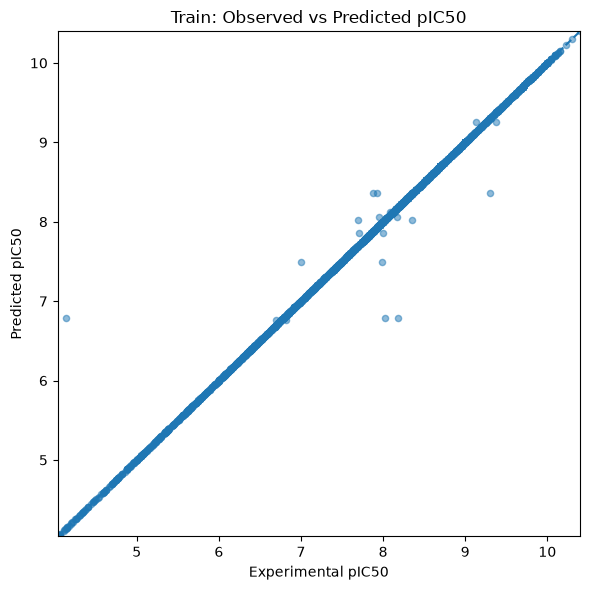

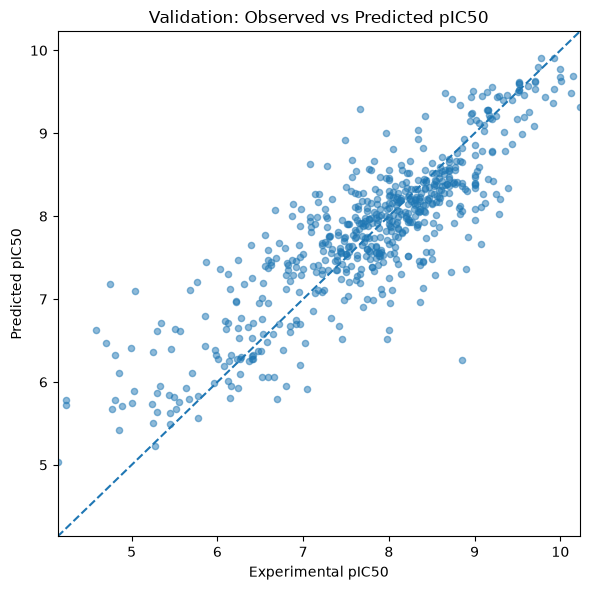

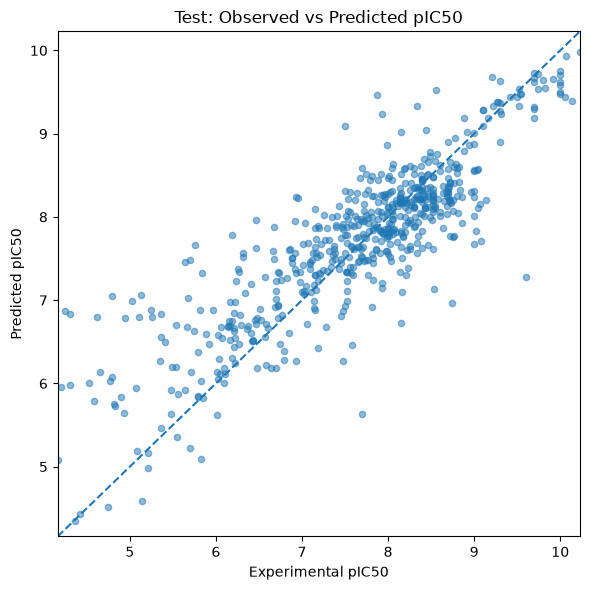

In [91]:
# ============================================================
# Step 18 — Observed vs Predicted pIC50
# ============================================================

import matplotlib.pyplot as plt


plot_data = [
    ("Train", y_train, train_predictions),
    ("Validation", y_validation, validation_predictions),
    ("Test", y_test, test_predictions),
]


for dataset_name, observed, predicted in plot_data:

    plt.figure(figsize=(6, 6))

    plt.scatter(
        observed,
        predicted,
        alpha=0.5,
        s=20,
    )

    plot_min = min(
        observed.min(),
        predicted.min(),
    )

    plot_max = max(
        observed.max(),
        predicted.max(),
    )

    plt.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        linestyle="--",
    )

    plt.xlabel(
        "Experimental pIC50"
    )

    plt.ylabel(
        "Predicted pIC50"
    )

    plt.title(
        f"{dataset_name}: Observed vs Predicted pIC50"
    )

    plt.xlim(
        plot_min,
        plot_max,
    )

    plt.ylim(
        plot_min,
        plot_max,
    )

    plt.tight_layout()
    plt.show()

## Step 19 — Evaluate Prediction Residuals

Residuals are examined to assess whether the final ExtraTrees model shows systematic prediction bias across the observed pIC50 range.

Residuals are defined as the difference between experimental and predicted pIC50 values.

Separate residual plots are generated for the training, validation, and test partitions. Ideally, residuals should be distributed around zero without a strong systematic pattern.

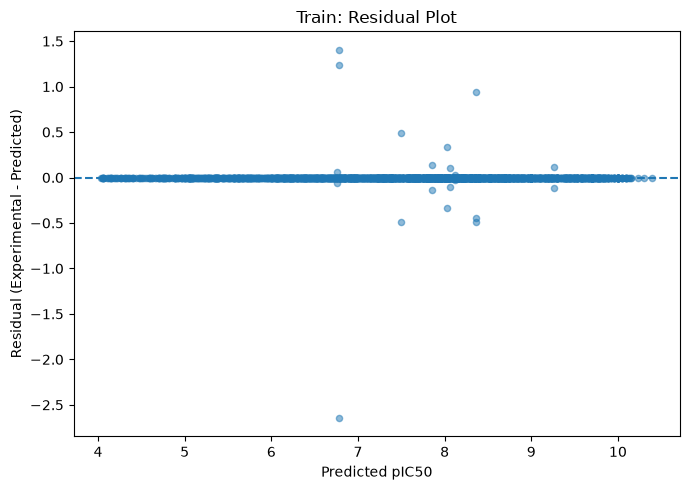

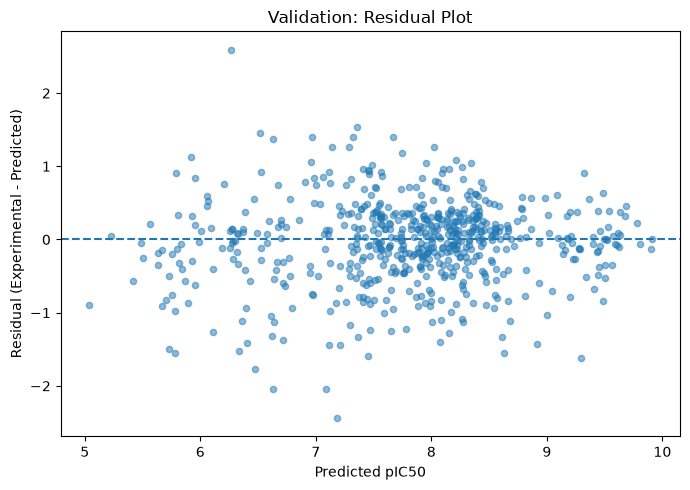

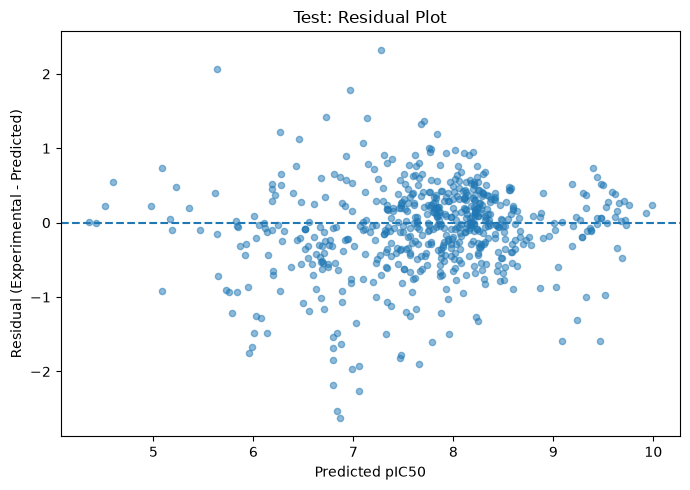

In [92]:
# ============================================================
# Step 19 — Residual Diagnostics
# ============================================================

import matplotlib.pyplot as plt


residual_plot_data = [
    (
        "Train",
        train_predictions,
        y_train - train_predictions,
    ),
    (
        "Validation",
        validation_predictions,
        y_validation - validation_predictions,
    ),
    (
        "Test",
        test_predictions,
        y_test - test_predictions,
    ),
]


for dataset_name, predicted, residuals in residual_plot_data:

    plt.figure(figsize=(7, 5))

    plt.scatter(
        predicted,
        residuals,
        alpha=0.5,
        s=20,
    )

    plt.axhline(
        y=0,
        linestyle="--",
    )

    plt.xlabel(
        "Predicted pIC50"
    )

    plt.ylabel(
        "Residual (Experimental - Predicted)"
    )

    plt.title(
        f"{dataset_name}: Residual Plot"
    )

    plt.tight_layout()
    plt.show()

### Residual Analysis Conclusion

Residual analysis showed that prediction errors for both the validation and test sets were generally distributed around zero, with no strong systematic bias across the predicted pIC50 range.

Several larger residuals were observed, particularly within the intermediate pIC50 range, indicating that a subset of compounds remains more difficult to predict accurately.

The similar residual patterns observed for the validation and test partitions are consistent with the comparable predictive performance obtained for both scaffold-separated datasets, supporting stable model generalization to structurally distinct compounds.

### Final QSAR Model Summary

The final MDM2 pIC50 QSAR model was developed using a combined molecular representation consisting of PaDEL 1D/2D descriptors and chirality-aware Morgan fingerprints.

The initial feature space contained 3,492 candidate predictive features:

- 1,444 PaDEL 1D/2D descriptors
- 2,048 Morgan fingerprint bits

After training-set missingness filtering, median imputation, and zero-variance feature removal, the final feature matrix contained 3,086 features:

- 1,092 PaDEL descriptors
- 1,994 Morgan fingerprint bits

The dataset contained 4,048 molecules and was partitioned using a Bemis–Murcko scaffold-based split:

- Training: 2,834 molecules
- Validation: 607 molecules
- Test: 607 molecules

The final ExtraTreesRegressor used 1,000 trees, `max_features = 0.20`, `min_samples_leaf = 1`, and `min_samples_split = 2`.

Final predictive performance was:

| Dataset | RMSE | MAE | R² |
|---|---:|---:|---:|
| Train | 0.0668 | 0.0034 | 0.9975 |
| Validation | 0.5814 | 0.4299 | 0.7307 |
| Test | 0.6119 | 0.4398 | 0.7321 |

The very similar validation and test R² values (~0.73) indicate consistent predictive performance on structurally distinct held-out compounds.

## Step 20 — Cumulative Feature-Importance Reduction

Following evaluation of the full ExtraTrees model, a feature-reduction analysis was performed to determine whether a more compact molecular representation could retain comparable predictive performance.

Features were ranked according to the impurity-based feature importance obtained from the full ExtraTrees model trained on the training partition.

Candidate subsets corresponding to 95%, 97.5%, 99%, and 100% cumulative feature importance were evaluated. For each subset, a new ExtraTrees model was trained using the same optimized hyperparameters and evaluated on the validation partition.

The smallest feature subset with validation RMSE no more than 0.005 above the best validation RMSE was selected.

Feature ranking and model fitting were based on the training data, while the validation set was used for feature-subset selection.

In [111]:
# ============================================================
# Step 21 — Evaluate the Validation-Selected Reduced Model
# on the Test Set
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)


# ------------------------------------------------------------
# 1. Reduce matrices using the selected feature subset
# ------------------------------------------------------------

X_train_selected = X_train[
    :,
    selected_feature_indices
]

X_validation_selected = X_validation[
    :,
    selected_feature_indices
]

X_test_selected = X_test[
    :,
    selected_feature_indices
]


print("Selected feature count:", X_train_selected.shape[1])

print(
    "Selected matrix shapes:",
    X_train_selected.shape,
    X_validation_selected.shape,
    X_test_selected.shape,
)


# ------------------------------------------------------------
# 2. Generate predictions
# ------------------------------------------------------------

train_pred_selected = (
    selected_reduced_model.predict(
        X_train_selected
    )
)

validation_pred_selected = (
    selected_reduced_model.predict(
        X_validation_selected
    )
)

test_pred_selected = (
    selected_reduced_model.predict(
        X_test_selected
    )
)


# ------------------------------------------------------------
# 3. Metric function
# ------------------------------------------------------------

def evaluate_split(y_true, y_pred):

    return {
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "R2": r2_score(
            y_true,
            y_pred
        ),
    }


# ------------------------------------------------------------
# 4. Evaluate reduced model
# ------------------------------------------------------------

reduced_metrics = {
    "Train": evaluate_split(
        y_train,
        train_pred_selected,
    ),
    "Validation": evaluate_split(
        y_validation,
        validation_pred_selected,
    ),
    "Test": evaluate_split(
        y_test,
        test_pred_selected,
    ),
}


reduced_metrics_df = (
    pd.DataFrame(
        reduced_metrics
    )
    .T
)

display(
    reduced_metrics_df.round(4)
)


# ------------------------------------------------------------
# 5. Compare full and reduced models
# ------------------------------------------------------------

comparison_df = pd.DataFrame(
    [
        {
            "Model": "Full model",
            "Features": 3086,
            "Validation_RMSE": 0.5814,
            "Validation_R2": 0.7307,
            "Test_RMSE": 0.6119,
            "Test_R2": 0.7321,
        },
        {
            "Model": "Reduced model",
            "Features": len(
                selected_feature_indices
            ),
            "Validation_RMSE":
                reduced_metrics[
                    "Validation"
                ]["RMSE"],
            "Validation_R2":
                reduced_metrics[
                    "Validation"
                ]["R2"],
            "Test_RMSE":
                reduced_metrics[
                    "Test"
                ]["RMSE"],
            "Test_R2":
                reduced_metrics[
                    "Test"
                ]["R2"],
        },
    ]
)

print("\nFull vs reduced model:")
display(
    comparison_df.round(4)
)

Selected feature count: 1278
Selected matrix shapes: (2834, 1278) (607, 1278) (607, 1278)


,RMSE,MAE,R2
Train,0.0717,0.0055,0.9971
Validation,0.5853,0.4345,0.7271
Test,0.6137,0.4401,0.7305



Full vs reduced model:


,Model,Features,Validation_RMSE,Validation_R2,Test_RMSE,Test_R2
0,Full model,3086,0.5814,0.7307,0.6119,0.7321
1,Reduced model,1278,0.5853,0.7271,0.6137,0.7305


## Step 21 — Final Evaluation of the Reduced ExtraTrees Model

The feature subset selected using validation performance is evaluated on the independent test partition.

The reduced model is compared with the full-feature ExtraTrees model to determine whether the reduction in molecular dimensionality results in a meaningful loss of predictive performance.

In [113]:
# ============================================================
# Step 21 — Final Reduced-Model Evaluation
# ============================================================

X_train_selected = X_train[
    :,
    selected_feature_indices
]

X_validation_selected = X_validation[
    :,
    selected_feature_indices
]

X_test_selected = X_test[
    :,
    selected_feature_indices
]


print(
    "Selected feature count:",
    X_train_selected.shape[1]
)

print(
    "Selected matrix shapes:",
    X_train_selected.shape,
    X_validation_selected.shape,
    X_test_selected.shape,
)


train_pred_selected = (
    selected_reduced_model.predict(
        X_train_selected
    )
)

validation_pred_selected = (
    selected_reduced_model.predict(
        X_validation_selected
    )
)

test_pred_selected = (
    selected_reduced_model.predict(
        X_test_selected
    )
)


reduced_metrics = {
    "Train":
        calculate_regression_metrics(
            y_train,
            train_pred_selected,
        ),

    "Validation":
        calculate_regression_metrics(
            y_validation,
            validation_pred_selected,
        ),

    "Test":
        calculate_regression_metrics(
            y_test,
            test_pred_selected,
        ),
}


reduced_metrics_df = (
    pd.DataFrame(
        reduced_metrics
    )
    .T
)

display(
    reduced_metrics_df.round(4)
)


comparison_df = pd.DataFrame(
    [
        {
            "Model": "Full model",
            "Features": 3086,
            "Validation_RMSE": 0.5814,
            "Validation_R2": 0.7307,
            "Test_RMSE": 0.6119,
            "Test_R2": 0.7321,
        },

        {
            "Model": "Reduced model",
            "Features":
                len(
                    selected_feature_indices
                ),
            "Validation_RMSE":
                reduced_metrics[
                    "Validation"
                ]["RMSE"],
            "Validation_R2":
                reduced_metrics[
                    "Validation"
                ]["R2"],
            "Test_RMSE":
                reduced_metrics[
                    "Test"
                ]["RMSE"],
            "Test_R2":
                reduced_metrics[
                    "Test"
                ]["R2"],
        },
    ]
)

display(
    comparison_df.round(4)
)

Selected feature count: 1278
Selected matrix shapes: (2834, 1278) (607, 1278) (607, 1278)


,RMSE,MAE,R2
Train,0.0717,0.0055,0.9971
Validation,0.5853,0.4345,0.7271
Test,0.6137,0.4401,0.7305


,Model,Features,Validation_RMSE,Validation_R2,Test_RMSE,Test_R2
0,Full model,3086,0.5814,0.7307,0.6119,0.7321
1,Reduced model,1278,0.5853,0.7271,0.6137,0.7305


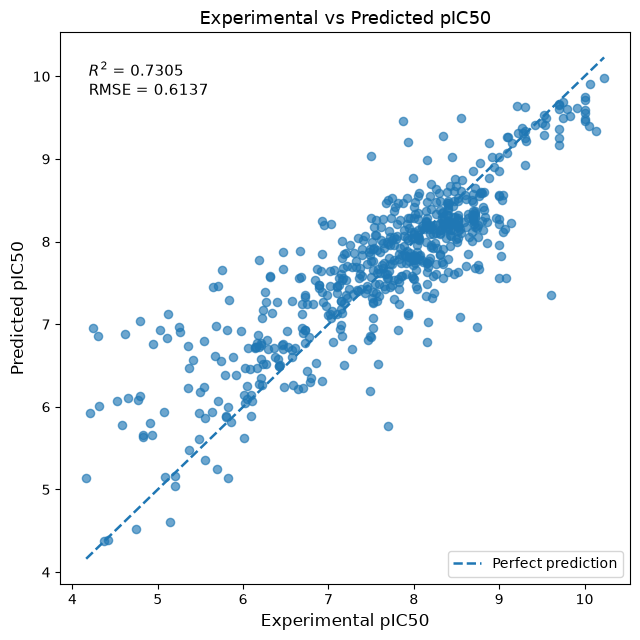

In [119]:
# ============================================================
# Step 22 — Publication-Ready Experimental vs Predicted pIC50
# Final Reduced ExtraTrees Model
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

plt.figure(figsize=(6.5, 6.5))

plt.scatter(
    y_test,
    test_pred_selected,
    alpha=0.65,
    s=35,
)


# ------------------------------------------------------------
# Perfect prediction line
# ------------------------------------------------------------

min_value = min(
    np.min(y_test),
    np.min(test_pred_selected),
)

max_value = max(
    np.max(y_test),
    np.max(test_pred_selected),
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=1.8,
    label="Perfect prediction",
)


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

plt.xlabel(
    "Experimental pIC50",
    fontsize=12,
)

plt.ylabel(
    "Predicted pIC50",
    fontsize=12,
)


# ------------------------------------------------------------
# Short publication-style title
# ------------------------------------------------------------

plt.title(
    "Experimental vs Predicted pIC50",
    fontsize=13,
)


# ------------------------------------------------------------
# Performance annotation
# ------------------------------------------------------------

plt.text(
    0.05,
    0.95,
    r"$R^2$ = 0.7305" + "\n" +
    "RMSE = 0.6137",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    fontsize=11,
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.legend(
    loc="lower right",
    frameon=True,
)

plt.tick_params(
    axis="both",
    labelsize=10,
)

plt.tight_layout()


# ------------------------------------------------------------
# Save for LaTeX / publication
# ------------------------------------------------------------

plt.savefig(
    "reduced_extratrees_test_predicted_vs_experimental.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.savefig(
    "reduced_extratrees_test_predicted_vs_experimental.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

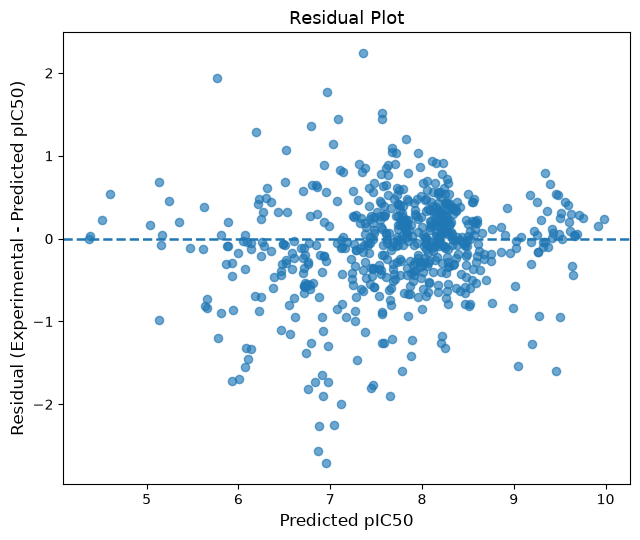

In [120]:
# ============================================================
# Step 23 — Residual Plot
# Final Reduced ExtraTrees Model
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


# ------------------------------------------------------------
# Calculate residuals
# residual = experimental - predicted
# ------------------------------------------------------------

test_residuals = (
    np.asarray(y_test) -
    np.asarray(test_pred_selected)
)


# ------------------------------------------------------------
# Plot predicted pIC50 vs residuals
# ------------------------------------------------------------

plt.figure(figsize=(6.5, 5.5))

plt.scatter(
    test_pred_selected,
    test_residuals,
    alpha=0.65,
    s=35,
)


# ------------------------------------------------------------
# Zero-residual reference line
# ------------------------------------------------------------

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1.8,
)


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xlabel(
    "Predicted pIC50",
    fontsize=12,
)

plt.ylabel(
    "Residual (Experimental - Predicted pIC50)",
    fontsize=12,
)

plt.title(
    "Residual Plot",
    fontsize=13,
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.tick_params(
    axis="both",
    labelsize=10,
)

plt.tight_layout()


# ------------------------------------------------------------
# Save for LaTeX / publication
# ------------------------------------------------------------

plt.savefig(
    "reduced_extratrees_test_residuals.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.savefig(
    "reduced_extratrees_test_residuals.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

In [121]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nSaved figure files:")
for f in os.listdir(os.getcwd()):
    if f.endswith((".pdf", ".png")):
        print(f)

Current working directory:
/Users/maryta/Downloads/mdm2_Reinvent_4_final/notebooks

Saved figure files:
reduced_model_test_predicted_vs_experimental.png
reduced_extratrees_test_residuals.pdf
reduced_extratrees_test_residuals.png
reduced_extratrees_test_predicted_vs_experimental.png
reduced_extratrees_test_predicted_vs_experimental.pdf


### Feature-Reduction Conclusion

The cumulative feature-importance analysis reduced the molecular representation from 3,086 to 1,278 features, corresponding to approximately 58.6% feature reduction.

Despite this substantial reduction, predictive performance remained nearly unchanged. The full model achieved a validation R² of 0.7307 and a test R² of 0.7321, whereas the reduced model achieved a validation R² of 0.7271 and a test R² of 0.7305. Test RMSE changed only slightly from 0.6119 to 0.6137.

These results indicate that the reduced feature set preserves essentially the same predictive performance while providing a more compact and computationally efficient model. Therefore, the 1,278-feature ExtraTrees model was selected for downstream deployment.


In [114]:
# ============================================================
# Step 22A — Check objects required for model bundle
# ============================================================

objects_to_check = [
    "selected_reduced_model",
    "selected_feature_indices",
    "combined_feature_names",
    "combined_feature_types",
    "imputer",
]

for name in objects_to_check:
    if name in globals():
        obj = globals()[name]

        if hasattr(obj, "shape"):
            info = obj.shape
        elif hasattr(obj, "__len__"):
            try:
                info = len(obj)
            except TypeError:
                info = type(obj).__name__
        else:
            info = type(obj).__name__

        print(f"✓ {name}: {info}")

    else:
        print(f"✗ {name}: NOT FOUND")

✓ selected_reduced_model: 1000
✓ selected_feature_indices: (1278,)
✓ combined_feature_names: 3086
✓ combined_feature_types: 3086
✓ imputer: SimpleImputer


In [115]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nSearching for standardized QSAR CSV files...\n")

matches = list(
    Path.cwd().rglob("*mdm2*pic50*standardized*.csv")
)

for path in matches:
    print(path)

Current working directory:
/Users/maryta/Downloads/mdm2_Reinvent_4_final/notebooks

Searching for standardized QSAR CSV files...



In [116]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

print("Project root:")
print(PROJECT_ROOT)

print("\nSearching entire project...\n")

matches = list(
    PROJECT_ROOT.rglob("*mdm2*pic50*standardized*.csv")
)

if matches:
    for i, path in enumerate(matches, start=1):
        print(f"{i}. {path}")
else:
    print("No matching standardized file found.")

Project root:
/Users/maryta/Downloads/mdm2_Reinvent_4_final

Searching entire project...

1. /Users/maryta/Downloads/mdm2_Reinvent_4_final/data/processed/mdm2_pic50_qsar_standardized.csv
